In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

df = pd.read_csv('online_shoppers_intention.csv')

print(f"{df.shape}")
df.head()

(12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


Missing values :
 Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


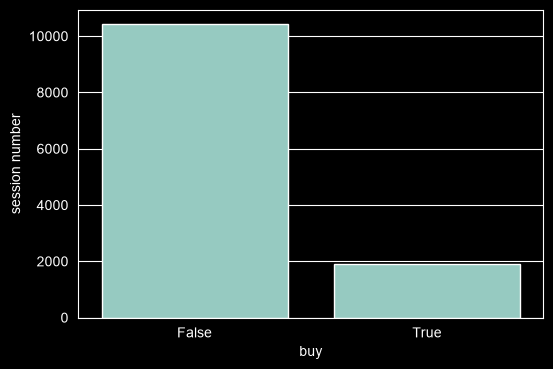

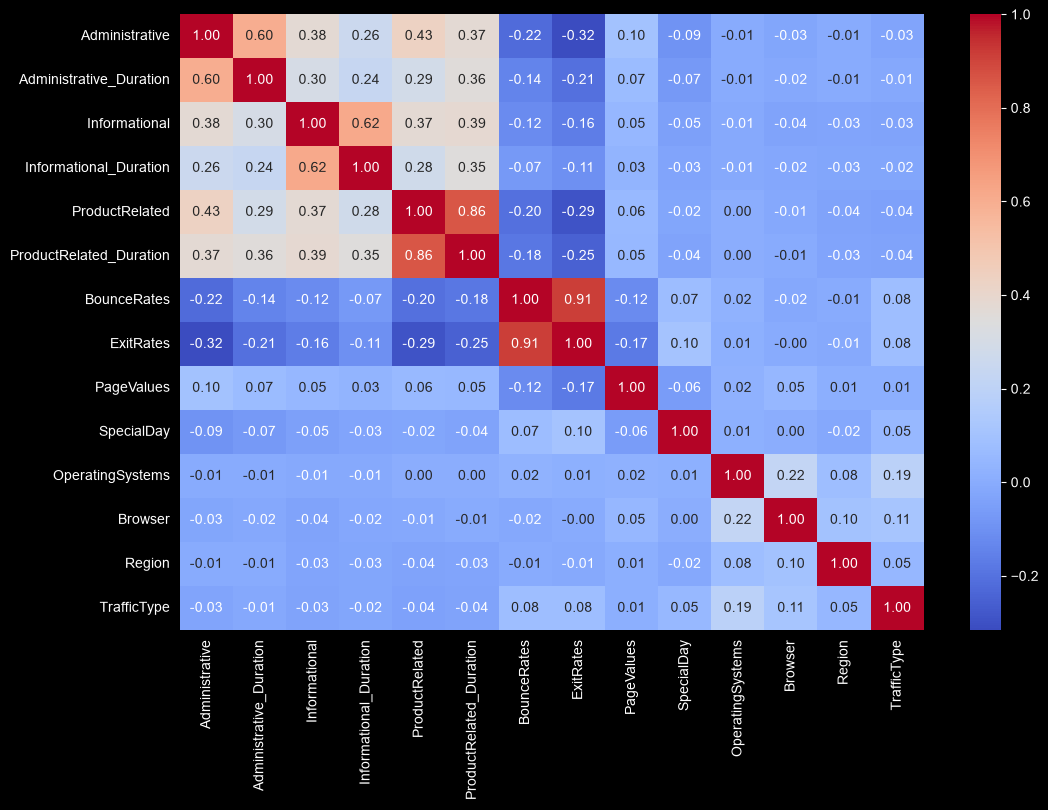

In [20]:

print("Missing values :\n", df.isnull().sum())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Revenue')

plt.xlabel("buy")
plt.ylabel("session number")
plt.show()

numeric_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(12, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [21]:

X = df.drop('Revenue', axis=1)
y = df['Revenue'].astype(int)
categorical_features = ['Month', 'VisitorType', 'Weekend']

numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
#regression
pipeline_lr = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', LogisticRegression(max_iter=1000))])

#Hyperparameters grid for regression
param_grid_lr = {
    'classifier__C': [0.1, 1, 10],
    'classifier__class_weight': [None, 'balanced']
}

grid_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=5, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train, y_train)

print(f"Best parameters for regression: {grid_lr.best_params_}")
print(f"F1 Score : {grid_lr.best_score_:.3f}")

#Random forest
pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(random_state=42))])

#Hyperparameters grid for Random Forest
param_grid_rf = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [10, None],
    'classifier__class_weight': [None, 'balanced']
}

grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print(f"Best parameters for random forest: {grid_rf.best_params_}")
print(f"F1 Score : {grid_rf.best_score_:.3f}")

Best parameters for regression: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced'}
F1 Score : 0.631


In [ ]:
#test set pred
y_pred_lr = grid_lr.predict(X_test)
y_pred_rf = grid_rf.predict(X_test)

print("Régression Logistique")

print(classification_report(y_test, y_pred_lr))

print("\nRandom forest")
print(classification_report(y_test, y_pred_rf))

# Best confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, cmap='Blues', ax=ax)
plt.title("Matrice de Confusion")
plt.xlabel("Prédiction")
plt.ylabel("Valeur Réelle")
plt.show()